# Direct Preference Optimization (DPO) Analysis

$$\mathcal{L}_{\text{DPO}}(\pi_\theta; \pi_{\text{ref}}) = -\mathbb{E}_{(x, a^{+}, a^{-}) \sim \mathcal{D}} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(a^{+} \mid x)}{\pi_{\text{ref}}(a^{+} \mid x)} - \beta \log \frac{\pi_\theta(a^{-} \mid x)}{\pi_{\text{ref}}(a^{-} \mid x)} \right) \right]$$

We need:
1. A **policy model** $\pi_\theta$
2. A frozen **reference model** $\pi_{\text{ref}}$
3. The **DPO loss function**
4. A **training loop** that handles both models

### Import the Necessary Packages

In [18]:
import gymnasium as gym
import numpy as np
from collections import deque
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

from pathlib import Path

from utils import load_preference_dataset, preference_pair_logps, show_video_of_model, show_video, evaluate_policy_returns

from policy import DiscretePolicy, ContinuousPolicy

In [19]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

### The DPO Loss Function

$$\mathcal{L}_{\text{DPO}} = -\log \sigma\left( \beta \cdot \left[ \left(\log \pi_\theta(a^{+}|x) - \log \pi_{\text{ref}}(a^{+}|x)\right) - \left(\log \pi_\theta(a^{-}|x) - \log \pi_{\text{ref}}(a^{-}|x)\right) \right] \right)$$

In [20]:
def dpo_loss(
    policy_chosen_logps: torch.FloatTensor,
    policy_rejected_logps: torch.FloatTensor,
    reference_chosen_logps: torch.FloatTensor,
    reference_rejected_logps: torch.FloatTensor,
    beta: float,
) -> Tuple[torch.FloatTensor, torch.FloatTensor, torch.FloatTensor]:
    """Compute the DPO loss for a batch of policy and reference model log probabilities."""
    # Step 1: Compute log-ratio of chosen vs rejected under the policy
    pi_logratios = policy_chosen_logps - policy_rejected_logps

    # Step 2: Compute log-ratio of chosen vs rejected under the reference
    ref_logratios = reference_chosen_logps - reference_rejected_logps

    # Step 3: The "logits" for the DPO loss
    logits = pi_logratios - ref_logratios

    # Step 4: DPO loss = -log sigmoid(beta * logits)
    losses = -F.logsigmoid(beta * logits)

    # Step 5: Compute implicit rewards for monitoring
    # r_hat(x, y) = beta * (log pi_theta(y|x) - log pi_ref(y|x))
    chosen_rewards = beta * (policy_chosen_logps - reference_chosen_logps).detach()
    rejected_rewards = beta * (policy_rejected_logps - reference_rejected_logps).detach()

    return losses, chosen_rewards, rejected_rewards

### Training Loop

- Load the preference dataset
- For each epoch:
  - Sample batches of $(x, a^{+}, a^{-})$ from the dataset
  - Compute the DPO loss using the current policy and the reference model
  - Update the policy parameters using backpropagation
  

In [21]:
def train_dpo(
    policy_model: nn.Module,
    reference_model: nn.Module,
    optimizer: optim.Optimizer,
    preference_data: Dict,
    n_epochs: int = 20,
    print_every: int = 1,
    beta: int = 0.1,
    early_stop: bool = False
 ):
    """Simple offline DPO training loop over a preference dataset."""
    scores = []
    pairs = preference_data['pairs']

    reference_model.eval()

    for epoch in range(1, n_epochs + 1):
        epoch_losses = []

        for pair in pairs:
            policy_chosen_logp, policy_rejected_logp = preference_pair_logps(policy_model, pair)
            with torch.no_grad():
                reference_chosen_logp, reference_rejected_logp = preference_pair_logps(reference_model, pair)

            loss, chosen_rewards, rejected_rewards = dpo_loss(
                policy_chosen_logps=policy_chosen_logp,
                policy_rejected_logps=policy_rejected_logp,
                reference_chosen_logps=reference_chosen_logp,
                reference_rejected_logps=reference_rejected_logp,
                beta=beta,
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        mean_loss = float(np.mean(epoch_losses))
        scores.append(mean_loss)

        if epoch % print_every == 0:
            print(f"Epoch {epoch}\tAverage Loss: {mean_loss:.4f}")

        if early_stop and mean_loss < 0.3:
            print(f"Stopped early at epoch {epoch}\tAverage Loss: {mean_loss:.4f}")
            break

    return scores


### Load Preference Dataset

$$(x, a^{+}, a^{-}) \sim \mathcal{D}$$

In [22]:
PREF_DIR = Path("../data_generation/outputs/preferences")
PREF_PATH = PREF_DIR / "Pendulum-v1_K1000_s5.json"
preference_data = load_preference_dataset(PREF_PATH)

env = gym.make(preference_data["env_id"])
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
env.close()

print(f"Loaded {len(preference_data['pairs'])} preference pairs from {PREF_PATH}")
print(f"Environment: {preference_data['env_id']}, Observation Dim: {state_dim}, Action Dim: {action_dim}")

Loaded 1000 preference pairs from ../data_generation/outputs/preferences/Pendulum-v1_K1000_s5.json
Environment: Pendulum-v1, Observation Dim: 3, Action Dim: 1


### Policy Model + Reference Model

In [23]:
hidden_dim = 32

policy_model = ContinuousPolicy(device, state_dim, action_dim, hidden_dim).to(device)
optimizer = optim.Adam(policy_model.parameters(), lr=1e-3)

# Fixed reference model
reference_model = ContinuousPolicy(device, state_dim, action_dim, hidden_dim).to(device)
reference_model.load_state_dict(policy_model.state_dict())
reference_model.eval() # fixed during training

ContinuousPolicy(
  (fc1): Linear(in_features=3, out_features=32, bias=True)
  (mu): Linear(in_features=32, out_features=1, bias=True)
)

In [24]:
scores = train_dpo(
    policy_model=policy_model,
    reference_model=reference_model,
    optimizer=optimizer,
    preference_data=preference_data,
    n_epochs=20,
    print_every=1,
    early_stop=False,
 )
print(f"Final average loss: {np.mean(scores[-5:]):.4f}")

Epoch 1	Average Loss: 0.0674
Final average loss: 0.0674


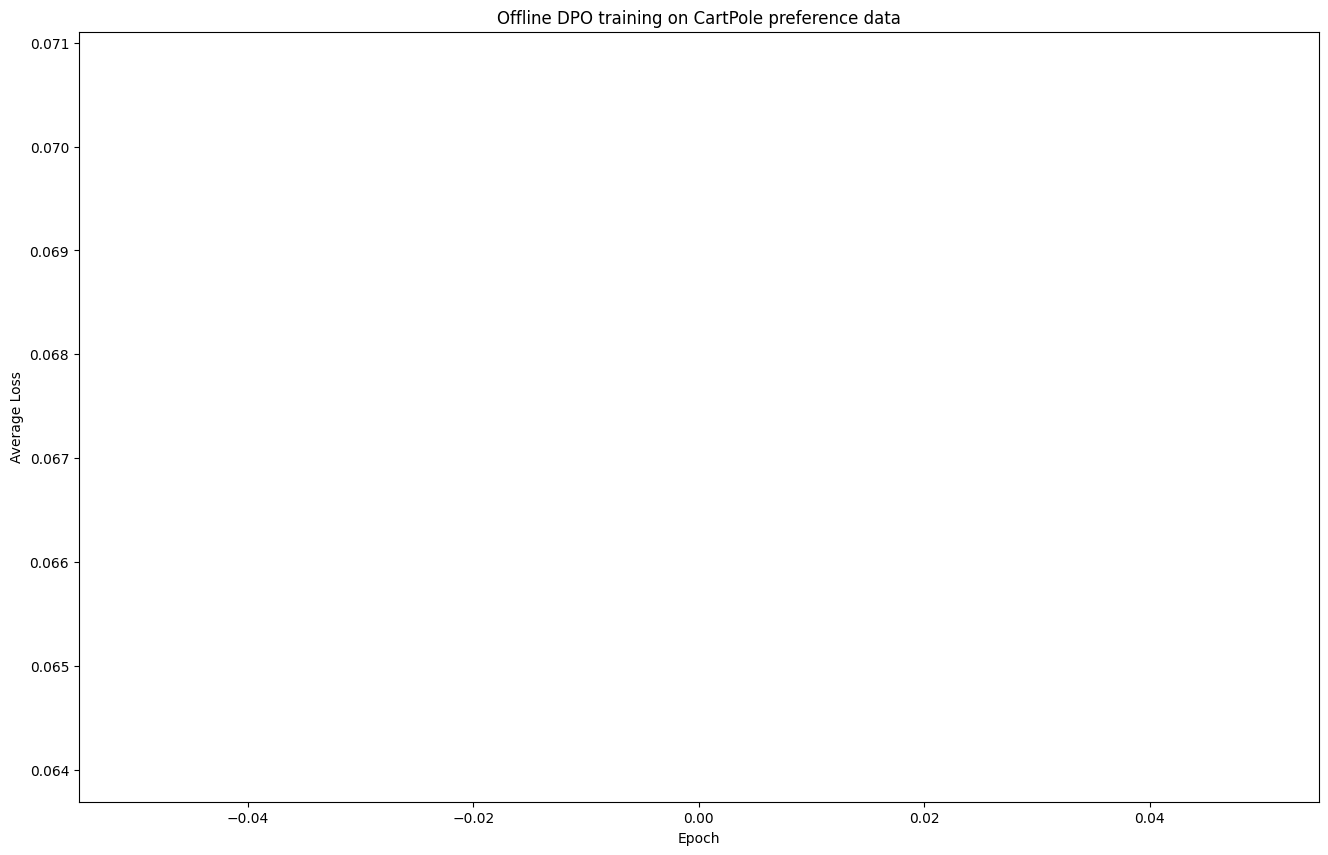

In [25]:
plt.plot(scores)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Offline DPO training on CartPole preference data")
plt.show()

In [26]:
save_path = './demos/'
# create video
policy = policy_model
show_video_of_model(save_path, policy, 'Pendulum-v1')
# show video
show_video(save_path, 'Pendulum-v1')

/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:78: DeprecationWarning: WARN: Recording ability for environment Pendulum-v1 initialized with `render_mode=None` is marked as deprecated and will be removed in the future.
  logger.deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:101: DeprecationWarning: WARN: <class 'gym.wrappers.monitoring.video_recorder.VideoRecorder'> is marked as deprecated and will be removed in the future.
  logger.deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(


In [27]:

eval_returns, eval_mean, eval_std = evaluate_policy_returns(
    policy_model, env_name='Pendulum-v1', n_episodes=50, max_t=200, deterministic=True
)

print(f"Evaluation over {len(eval_returns)} episodes")
print(f"Mean episode return: {eval_mean:.2f}")
print(f"Std episode return:  {eval_std:.2f}")

/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/home/pedro/miniconda3/envs/mnlp_exercises/lib/python3.10/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


Evaluation over 50 episodes
Mean episode return: -1459.94
Std episode return:  229.57
